In [326]:
 # 单元 1：参数区
n = 10
W = 100
seed_count = 20
seed_source = 2026

# 单个 seed 查看时改这里
seed_to_view = None

In [327]:
# 单元 2：导入库
import random
import pandas as pd
import matplotlib.pyplot as plt

In [328]:
# 单元 3：函数与类定义

def generate_r(rng):
    r = rng.random()

    if r < 0.25:
        return [round(rng.uniform(1.0, 1.5), 2), round(rng.uniform(0.6, 0.8), 2)]
    elif r < 0.5:
        return [round(rng.uniform(1.5, 2.0), 2), round(rng.uniform(0.5, 0.7), 2)]
    elif r < 0.75:
        return [round(rng.uniform(2.0, 2.5), 2), round(rng.uniform(0.4, 0.6), 2)]
    else:
        return [round(rng.uniform(2.5, 3.0), 2), round(rng.uniform(0.3, 0.5), 2)]


class Item:
    def __init__(self, id, w, v):
        self.id = id
        self.w = w
        self.v = v
        self.ratio = v / w if w != 0 else float("inf")


class Node:
    def __init__(self, level, cw, cv, ub=0, choose=None, parent=None):
        self.level = level
        self.cw = cw
        self.cv = cv
        self.ub = ub
        self.choose = choose
        self.parent = parent


def greedy_knapsack(items, W):
    selected_items = []
    total_weight = 0
    total_value = 0

    for item in items:
        if total_weight + item.w <= W:
            selected_items.append(item)
            total_weight += item.w
            total_value += item.v

    return selected_items, total_weight, total_value


def build_path_table(path):
    rows = []
    cum_w = 0
    cum_v = 0

    for item in path:
        cum_w += item.w
        cum_v += item.v
        rows.append({
            "path_node": item.id,
            "w": round(item.w, 2),
            "v": round(item.v, 2),
            "cum_w": round(cum_w, 2),
            "cum_v": round(cum_v, 2)
        })

    return pd.DataFrame(rows)


def generate_seed_table(seed_count, seed_min=0, seed_max=10**6, seed_source=2026):
    seed_rng = random.Random(seed_source)
    seed_list = seed_rng.sample(range(seed_min, seed_max), seed_count)
    seed_df = pd.DataFrame({
        "序号": range(1, seed_count + 1),
        "seed": seed_list
    })
    return seed_list, seed_df


def run_once(seed, n=10, W=100):
    rng = random.Random(seed)

    # 1. 随机数据生成
    lst = [generate_r(rng) for _ in range(n)]
    profit_list = [row[0] for row in lst]
    R_list = [row[1] for row in lst]
    list_value = [round(rp[1] * rp[0] - (1 - rp[1]), 2) for rp in lst]
    list_items = list(range(1, len(list_value) + 1))
    list_weight = [round(rng.uniform(5, 20), 2) for _ in range(len(list_value))]

    items_df = pd.DataFrame({
        "物件": list_items,
        "profit": profit_list,
        "R": R_list,
        "w": list_weight,
        "v": list_value
    })

    # 2. 构造 Item 列表
    list_items_final = [Item(id, w, v) for id, w, v in zip(list_items, list_weight, list_value)]
    list_items_final.sort(key=lambda x: x.ratio, reverse=True)

    # 3. 分支定界法
    def expand(node):
        next_level = node.level + 1
        if next_level >= len(list_items_final):
            return
        item = list_items_final[next_level]
        yield Node(next_level, node.cw + item.w, node.cv + item.v, choose=item, parent=node)
        yield Node(next_level, node.cw, node.cv, choose=None, parent=node)

    def bound(node):
        if node.cw > W:
            return 0
        if node.cw == W:
            return node.cv

        profit = node.cv
        weight = node.cw
        i = node.level + 1

        while i < len(list_items_final) and weight + list_items_final[i].w <= W:
            weight += list_items_final[i].w
            profit += list_items_final[i].v
            i += 1

        if i < len(list_items_final):
            profit += (W - weight) * list_items_final[i].v / list_items_final[i].w

        return profit

    def branch_and_bound():
        root = Node(-1, 0, 0)
        root.ub = bound(root)

        best = 0
        best_node = root
        waiting_nodes = [root]

        while waiting_nodes:
            node = waiting_nodes.pop()

            if node.ub <= best:
                continue

            for child in expand(node):
                if child.cw > W:
                    continue

                if child.cv > best:
                    best = child.cv
                    best_node = child

                child.ub = bound(child)

                if child.ub > best:
                    waiting_nodes.append(child)

        return best, best_node

    answer, best_node = branch_and_bound()

    path = []
    current = best_node
    while current is not None:
        if current.choose is not None:
            path.append(current.choose)
        current = current.parent
    path.reverse()

    bnb_weight = sum(item.w for item in path)
    bnb_value = answer

    # 4. 贪心法
    selected_items, greedy_weight, greedy_value = greedy_knapsack(list_items_final, W)

    # 5. 偏差率
    greedy_deviation_rate = 0.0 if abs(bnb_value) < 1e-12 else (bnb_value - greedy_value) / abs(bnb_value)
    same_result = abs(bnb_value - greedy_value) < 1e-6

    summary_df = pd.DataFrame({
        "指标": [
            "Seed",
            "贪心法总重",
            "贪心法总价值",
            "分支法总重",
            "分支法总价值",
            "贪心偏差率",
            "是否一致"
        ],
        "结果": [
            seed,
            round(greedy_weight, 2),
            round(greedy_value, 4),
            round(bnb_weight, 2),
            round(bnb_value, 4),
            round(greedy_deviation_rate, 6),
            same_result
        ]
    })

    return {
        "seed": seed,
        "items_df": items_df,
        "summary_df": summary_df,
        "bnb_path_df": build_path_table(path),
        "greedy_path_df": build_path_table(selected_items),
        "bnb_value": bnb_value,
        "greedy_value": greedy_value,
        "bnb_weight": bnb_weight,
        "greedy_weight": greedy_weight,
        "greedy_deviation_rate": greedy_deviation_rate,
        "same_result": same_result
    }


def run_batch(seeds, n=10, W=100):
    rows = []
    for i, seed in enumerate(seeds, start=1):
        result = run_once(seed, n=n, W=W)
        rows.append({
            "序号": i,
            "seed": seed,
            "greedy_value": round(result["greedy_value"], 4),
            "bnb_value": round(result["bnb_value"], 4),
            "greedy_weight": round(result["greedy_weight"], 4),
            "bnb_weight": round(result["bnb_weight"], 4),
            "greedy_deviation_rate": round(result["greedy_deviation_rate"], 6),
            "same_result": result["same_result"]
        })
    return pd.DataFrame(rows)


def plot_batch_statistics(stats_df):
    plt.figure(figsize=(10, 4))
    plt.plot(stats_df["seed"], stats_df["greedy_deviation_rate"], marker="o")
    plt.xlabel("seed")
    plt.ylabel("greedy_deviation_rate")
    plt.title("Greedy Deviation Rate by Seed")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(stats_df["seed"], stats_df["greedy_value"], marker="o", label="Greedy")
    plt.plot(stats_df["seed"], stats_df["bnb_value"], marker="o", label="Branch and Bound")
    plt.xlabel("seed")
    plt.ylabel("value")
    plt.title("Greedy vs Branch and Bound")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(stats_df["greedy_deviation_rate"], bins=20)
    plt.xlabel("greedy_deviation_rate")
    plt.ylabel("frequency")
    plt.title("Distribution of Greedy Deviation Rate")
    plt.grid(True)
    plt.show()

In [329]:
# 单元 4：生成 seed 表
def generate_seed_table(seed_count, seed_min=0, seed_max=10**6, seed_source=2026):
    seed_rng = random.Random(seed_source)
    seed_list = seed_rng.sample(range(seed_min, seed_max), seed_count)
    seed_df = pd.DataFrame({
        "序号": range(1, seed_count + 1),
        "seed": seed_list
    })
    return seed_list, seed_df


seed_list, seed_df = generate_seed_table(seed_count, seed_source=seed_source)
seed_df

,序号,seed
0,1,124906
1,2,335003
2,3,526925
3,4,997554
4,5,536685
5,6,678636
6,7,901775
7,8,999241
8,9,107622
9,10,927066


In [330]:
# 单元 5：批量实验
def run_batch(seeds, n=10, W=100):
    rows = []
    for i, seed in enumerate(seeds, start=1):
        result = run_once(seed, n=n, W=W)
        rows.append({
            "序号": i,
            "seed": seed,
            "greedy_value": round(result["greedy_value"], 4),
            "bnb_value": round(result["bnb_value"], 4),
            "greedy_weight": round(result["greedy_weight"], 4),
            "bnb_weight": round(result["bnb_weight"], 4),
            "greedy_deviation_rate": round(result["greedy_deviation_rate"], 6),
            "same_result": result["same_result"],
            "是否命中最优": "是" if result["same_result"] else "否"
        })
    return pd.DataFrame(rows)


stats_df = run_batch(seed_list, n=n, W=W)
stats_df

,序号,seed,greedy_value,bnb_value,greedy_weight,bnb_weight,greedy_deviation_rate,same_result,是否命中最优
0,1,124906,4.85,4.85,97.07,97.07,0.000000,True,是
1,2,335003,4.47,4.71,86.22,97.24,0.050955,False,否
2,3,526925,6.29,6.29,92.72,92.72,0.000000,True,是
3,4,997554,4.30,4.30,95.07,95.07,0.000000,True,是
4,5,536685,5.11,5.32,87.17,94.58,0.039474,False,否
5,6,678636,3.94,3.94,95.10,95.10,0.000000,True,是
6,7,901775,4.51,4.51,98.36,98.36,0.000000,True,是
7,8,999241,4.71,4.87,92.77,97.23,0.032854,False,否
8,9,107622,4.87,4.97,97.27,95.90,0.020121,False,否
9,10,927066,5.17,5.17,93.89,93.89,0.000000,True,是


In [331]:
# 单元 6：总体统计
summary_df = pd.DataFrame({
    "指标": [
        "样本数",
        "贪心平均偏差率",
        "贪心中位数偏差率",
        "贪心最大偏差率",
        "贪心最小偏差率",
        "Greedy 命中最优比例",
        "Greedy 未命中最优比例"
    ],
    "结果": [
        len(stats_df),
        stats_df["greedy_deviation_rate"].mean(),
        stats_df["greedy_deviation_rate"].median(),
        stats_df["greedy_deviation_rate"].max(),
        stats_df["greedy_deviation_rate"].min(),
        stats_df["same_result"].mean(),
        1 - stats_df["same_result"].mean()
    ]
})

summary_df

,指标,结果
0,样本数,20.000000
1,贪心平均偏差率,0.011575
2,贪心中位数偏差率,0.000000
3,贪心最大偏差率,0.050955
4,贪心最小偏差率,0.000000
5,Greedy 命中最优比例,0.550000
6,Greedy 未命中最优比例,0.450000


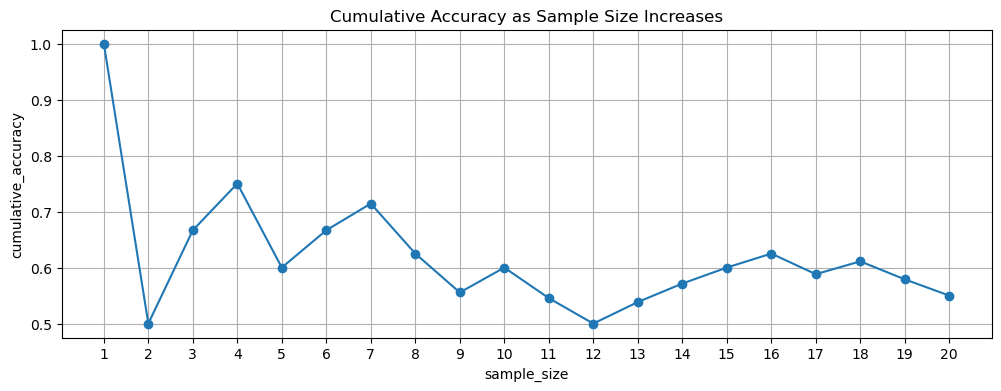

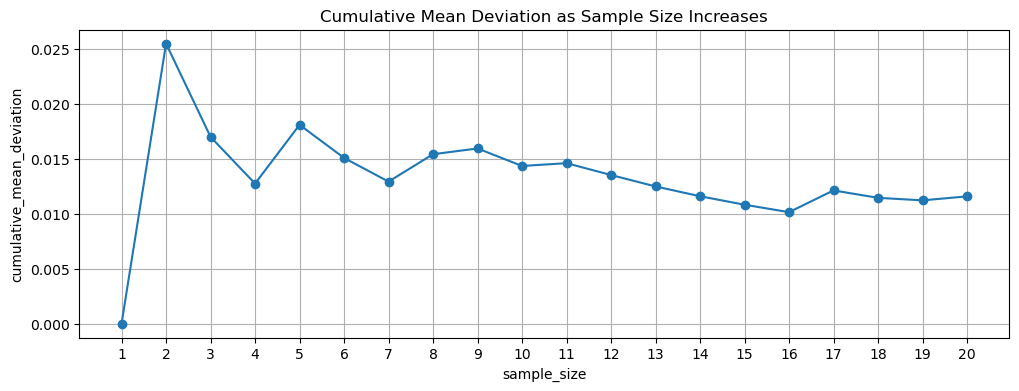

In [332]:
# 单元 7：只保留准确率和累计平均偏差率
def plot_batch_statistics(stats_df):
    plot_df = stats_df.copy().reset_index(drop=True)
    plot_df["sample_id"] = range(1, len(plot_df) + 1)

    # 累计准确率：到第k个样本为止，Greedy命中最优的比例
    plot_df["cum_accuracy"] = plot_df["same_result"].astype(int).expanding().mean()

    # 累计平均偏差率：到第k个样本为止，Greedy平均偏差率
    plot_df["cum_mean_deviation"] = plot_df["greedy_deviation_rate"].expanding().mean()

    x_vals = plot_df["sample_id"].tolist()

    # 图1：样本数增加时，累计准确率变化
    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["sample_id"], plot_df["cum_accuracy"], marker="o")
    plt.xlabel("sample_size")
    plt.ylabel("cumulative_accuracy")
    plt.title("Cumulative Accuracy as Sample Size Increases")
    plt.xticks(x_vals)
    plt.grid(True)
    plt.show()

    # 图2：样本数增加时，累计平均偏差率变化
    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["sample_id"], plot_df["cum_mean_deviation"], marker="o")
    plt.xlabel("sample_size")
    plt.ylabel("cumulative_mean_deviation")
    plt.title("Cumulative Mean Deviation as Sample Size Increases")
    plt.xticks(x_vals)
    plt.grid(True)
    plt.show()

    return plot_df


plot_df = plot_batch_statistics(stats_df)

In [333]:
# 单元 8A：先看 seed 表
seed_df

,序号,seed
0,1,124906
1,2,335003
2,3,526925
3,4,997554
4,5,536685
5,6,678636
6,7,901775
7,8,999241
8,9,107622
9,10,927066


In [334]:
# 单元 8：用下拉框选择 seed number（重跑时保留当前选择）

import ipywidgets as widgets
from IPython.display import display

# 如果之前已经有 seed_selector，就尽量保留它当前的值
previous_seed = None
if "seed_selector" in globals():
    try:
        previous_seed = seed_selector.value
    except Exception:
        previous_seed = None

# 如果之前的值已经不在新的 seed_list 里，就回到第一个
if previous_seed not in seed_list:
    previous_seed = seed_list[0]

seed_selector = widgets.Dropdown(
    options=[(f"No.{i} | seed={s}", s) for i, s in zip(seed_df["序号"], seed_df["seed"])],
    value=previous_seed,
    description="Select:"
)

display(seed_selector)


Dropdown(description='Select:', index=1, options=(('No.1 | seed=124906', 124906), ('No.2 | seed=335003', 33500…

In [335]:
# 单元 9：运行当前选中的 seed
seed_to_view = seed_selector.value
print("Current seed =", seed_to_view)

detail = run_once(seed_to_view, n=n, W=W)


Current seed = 335003


In [336]:
# 单元 10：显示单个 seed 的初始物件表
detail["items_df"]

,物件,profit,R,w,v
0,1,2.94,0.45,14.48,0.77
1,2,1.08,0.71,11.72,0.48
2,3,1.53,0.65,18.26,0.64
3,4,2.88,0.36,7.24,0.40
4,5,2.16,0.59,17.54,0.86
5,6,2.37,0.41,19.40,0.38
6,7,2.32,0.58,15.84,0.93
7,8,2.46,0.41,10.69,0.42
8,9,1.64,0.61,8.71,0.61
9,10,2.55,0.31,16.80,0.10


In [337]:
# 单元 11：显示单个 seed 的关键数据
detail["summary_df"]

,指标,结果
0,Seed,335003
1,贪心法总重,86.22
2,贪心法总价值,4.47
3,分支法总重,97.24
4,分支法总价值,4.71
5,贪心偏差率,0.050955
6,是否一致,False


In [338]:
# 单元 12：显示 Branch and Bound 路径
detail["bnb_path_df"]

,path_node,w,v,cum_w,cum_v
0,9,8.71,0.61,8.71,0.61
1,7,15.84,0.93,24.55,1.54
2,1,14.48,0.77,39.03,2.31
3,5,17.54,0.86,56.57,3.17
4,2,11.72,0.48,68.29,3.65
5,8,10.69,0.42,78.98,4.07
6,3,18.26,0.64,97.24,4.71


In [339]:
# 单元 13：显示 Greedy 路径
detail["greedy_path_df"]

,path_node,w,v,cum_w,cum_v
0,9,8.71,0.61,8.71,0.61
1,7,15.84,0.93,24.55,1.54
2,4,7.24,0.40,31.79,1.94
3,1,14.48,0.77,46.27,2.71
4,5,17.54,0.86,63.81,3.57
5,2,11.72,0.48,75.53,4.05
6,8,10.69,0.42,86.22,4.47
